In [ ]:
import sys
import pandas as pd 
import numpy as np

pd.options.mode.chained_assignment = None  # default='warn'


MODULES_PATH = "../modules"
if MODULES_PATH not in sys.path:
    sys.path.append(MODULES_PATH)

from assets_etl import *

In [ ]:
import pickle 
with open('../Data/sentiment_dict.pickle', 'rb') as f:
    tweet_dict = pickle.load(f)

In [ ]:
tweet_dict.keys()

In [ ]:
example_df = tweet_dict['TESLA']['neutral'].head() # Remove this cell later

In [ ]:
def apply_to_each_df(tweet_dict, *funcs) -> None:
    """
    Applies a list of functions to each dataframe in the tweet_dict (in place)
    @param tweet_dict: dictionary of dataframes
    @param *funcs: list of functions to apply to each dataframe
    @return: None
    """
    for security in tweet_dict.keys():
        for sentiment, df in tweet_dict[security].items():
            for func in funcs:
                df = func(df,security, sentiment)
                tweet_dict[security][sentiment] = df   


In [ ]:
import copy
tweet_dict_copy = copy.deepcopy(tweet_dict) # TODO: before removing this cell, rename all elements from tweet_df_copy to tweet_dict

In [ ]:
import datetime as dt
start_date = dt.datetime(2010,1,1)
end_date = dt.datetime(2022,12,31)

date_format = '%Y-%m-%d'

def remove_outside_dates(df, *args):
    df = df[(df['day'] >= start_date) & (df['day'] <= end_date)]
    return df

def remove_day_column_rename_created_at(df, *args):
    df = df.drop(columns=['created_at'])
    df = df.rename(columns={'day': 'created_at'})
    return df

def set_created_at_as_index(df, *args):
    df = df.set_index('created_at')
    return df

# Pre-process dataframe and restrict date range
apply_to_each_df(tweet_dict_copy, 
                    remove_outside_dates,
                    remove_day_column_rename_created_at, set_created_at_as_index)

In [ ]:
import yfinance as yf

ticker_names = {
    'TESLA': {'ticker':'TSLA', 'type':'stock', 'permno': 93436},
    'TWITTER': {'ticker': 'TWTR', 'type': 'stock', 'permno': 14295},
    'BITCOIN': {'ticker':'BTC-USD', 'type':'crypto'},
    'ETH': {'ticker':'ETH-USD', 'type':'crypto'},
    'DOGE': {'ticker':'DOGE-USD', 'type':'crypto'},
}


In [ ]:
#Download data for each security
"""wrds_loader = WRDSLoader(username="safae")
for security in ticker_names.keys():
    ticker = ticker_names[security]['ticker']
    type_ = ticker_names[security]['type']

    path = f'../Data/securities/'

    if type_ == 'crypto':
        yf.download(ticker, start=start_date.strftime(
            date_format), end=end_date.strftime(date_format),
                    progress=False, interval='1d').to_csv(path + f'{security}.csv')

    else: 

        permno = ticker_names[security]['permno']
        
        wrds_loader.download_stock_data({ticker: permno}, from_=start_date.strftime(
            date_format), to=end_date.strftime(date_format), save_to=path, close_conn=False)
wrds_loader.close()"""
pass

In [ ]:
#Load data for each security
returns_dict = {}
for security in ticker_names.keys():
  ticker = ticker_names[security]['ticker']
  type_ = ticker_names[security]['type']

  path = f'../Data/securities/'

  df = None

  if type_ == 'crypto':
    df = pd.read_csv(path + f'{ticker}.csv', parse_dates=True)

    df = preproc_btc_for_bsts(df)

  else:
    df = pd.read_csv(path + f'{ticker}_2010_2022.csv', parse_dates=True)

    df = preproc_tsla_for_bsts(df)

    df.rename(columns={'index': 'date'}, inplace=True)
  
  
  df = df[['date', 'ret']]
  df['log_return'] = np.log(df['ret'] + 1)
  df.set_index('date', inplace=True)

  returns_dict[security] = df


In [ ]:
# Add returns before and after tweet to the df
from datetime import timedelta
pre_effect_window = 14
post_effect_window = 7


def add_log_returns_before_and_after_tweet(df,*args):
    
    security = args[0]
    prices_df = returns_dict[security]

    df['log_returns_before_tweet'] = df.index.map(
        lambda x: prices_df.loc[x - timedelta(days=pre_effect_window): x - timedelta(days=1)]['log_return'].values
        )

    df['log_returns_after_tweet'] = df.index.map(
        lambda x: prices_df.loc[x + timedelta(days=1):  x + timedelta(days=post_effect_window)]['log_return'].values)
    
    df = df[(df['log_returns_before_tweet'].map(len) == pre_effect_window)
            & (df['log_returns_after_tweet'].map(len) == post_effect_window)]

    return df


apply_to_each_df(tweet_dict_copy, add_log_returns_before_and_after_tweet)

In [ ]:
# count number of nans
pd.set_option('display.max_colwidth', None)
tweet_dict_copy['BITCOIN']['neutral'][['log_returns_before_tweet','log_returns_after_tweet']]


In [ ]:
pd.set_option('display.max_row', None)
returns_dict['BITCOIN']

In [45]:
# perform t-test on the returns/prices before and after the tweet
from scipy.stats import ttest_ind

def perform_t_test(df, *args):

    def ttt(x):
    
        before = np.array(x['log_returns_before_tweet'].tolist())
        after = np.array(x['log_returns_after_tweet'].tolist())


        return ttest_ind(
            before, after)

    df['t_stat'] = df.apply(lambda x: ttt(x) , axis=1)
    df['p_value'] = df['t_stat'].apply(lambda x: x[1])
    df['t_stat'] = df['t_stat'].apply(lambda x: x[0])

    return df 

apply_to_each_df(tweet_dict_copy, perform_t_test)

In [46]:
tweet_dict_copy['BITCOIN']['neutral'][['log_returns_before_tweet','log_returns_after_tweet', 't_stat', 'p_value']]

,log_returns_before_tweet,log_returns_after_tweet,t_stat,p_value
created_at,,,,
2022-12-08,"[0.014059925050602523, -0.008496893859067009, 0.0027656878176285063, -0.0015627479130952467, -0.015067422286753254, 0.0038095785152118156, 0.029407493656405128, 0.013274187408105525, -0.0035074670941434355, 0.0011075541755852362, 0.0016756065036876836, 0.007003266823068687, -0.007867434364714435, -0.005062472260756016]","[0.009488460812235847, -0.001276884745665299, -1.5926473388427275e-06, -0.00658871701364835, 0.0268950241692265, 0.02858694861117855, -0.024955489673310183]",-0.357633,0.724560
2022-12-05,"[-0.034069366709232544, 0.0006076430252312466, 0.027785004474197614, 0.014059925050602523, -0.008496893859067009, 0.0027656878176285063, -0.0015627479130952467, -0.015067422286753254, 0.0038095785152118156, 0.029407493656405128, 0.013274187408105525, -0.0035074670941434355, 0.0011075541755852362, 0.0016756065036876836]","[-0.007867434364714435, -0.005062472260756016, 0.005794286570931608, 0.009488460812235847, -0.001276884745665299, -1.5926473388427275e-06, -0.00658871701364835]",0.473987,0.640911
2022-11-22,"[-0.08211628222446955, -0.11025573009573592, -0.011291550227639367, 0.008991903477732544, -0.014017441885523972, -0.014249101264893359, -0.00782608707221231, 0.018392758352331246, -0.0060941493638353855, -0.006106680046560695, 0.009731793394666078, -0.0042877728556945105, -0.011235630967318654, -0.034069366709232544]","[0.027785004474197614, 0.014059925050602523, -0.008496893859067009, 0.0027656878176285063, -0.0015627479130952467, -0.015067422286753254, 0.0038095785152118156]",-1.576705,0.131368
2022-11-18,"[0.0227025872823321, 0.027328665052311876, -0.006578324146873815, -0.01723846680690027, -0.08211628222446955, -0.11025573009573592, -0.011291550227639367, 0.008991903477732544, -0.014017441885523972, -0.014249101264893359, -0.00782608707221231, 0.018392758352331246, -0.0060941493638353855, -0.006106680046560695]","[-0.0042877728556945105, -0.011235630967318654, -0.034069366709232544, 0.0006076430252312466, 0.027785004474197614, 0.014059925050602523, -0.008496893859067009]",-0.773904,0.448511
2022-11-14,"[-0.009247847321648508, -0.0018429682507198298, -0.004330304303060425, -0.008895926314198648, 0.0227025872823321, 0.027328665052311876, -0.006578324146873815, -0.01723846680690027, -0.08211628222446955, -0.11025573009573592, -0.011291550227639367, 0.008991903477732544, -0.014017441885523972, -0.014249101264893359]","[0.018392758352331246, -0.0060941493638353855, -0.006106680046560695, 0.009731793394666078, -0.0042877728556945105, -0.011235630967318654, -0.034069366709232544]",-0.741119,0.467683
...,...,...,...,...
2018-02-25,"[-0.051286560562218836, 0.03445789167942878, 0.01659097593313042, 0.03966372323874455, 0.080147054371977, 0.026072324807378755, 0.05503514340583675, 0.018010593386227926, 0.005117039788132426, 0.06242061772801067, -0.05735705543487898, -0.042893723400227, -0.036719133952008425, -0.00384925395951514]","[0.032895377630057766, 0.05587010003406676, 0.016819022902861195, -0.0036327029672044934, 0.02919359128412309, 0.02205628037327072, 0.005228009389833477]",-0.697824,0.493739
2018-02-22,"[0.028223119793553447, 0.025905336301529334, 0.0467967807695782, -0.051286560562218836, 0.03445789167942878, 0.01659097593313042, 0.03966372323874455, 0.080147054371977, 0.026072324807378755, 0.05503514340583675, 0.018010593386227926, 0.005117039788132426, 0.06242061772801067, -0.05735705543487898]","[-0.036719133952008425, -0.00384925395951514, -0.041242170628449884, 0.032895377630057766, 0.05587010003406676, 0.016819022902861195, -0.0036327029672044934]",1.191046,0.248303
2018-01-29,"[0.01100483265482185, -0.15567805196972231, -0.13129742898327998, 0.08931860159460801, 0.004981092565845538, 0.06655896829741544, -0.023501728343100214, -0.08530584828490298, -0.031997165069988114, 0.029047731867729736, 0.031208992848457448, -0.031850545734588016, 0.021332749386505194, 0.039532682413202985]","[-0.07713140554607342, -0.057090769

In [61]:
#Write results of significance test to file
with open('results.txt', 'a') as f:
    f.write(
        f'For Window Size: {pre_effect_window} days before and {post_effect_window} days after\n')
    
    f.write('Percentge of significant p-values for each security and sentiment:\n')
    for security in tweet_dict_copy.keys():
        f.write(f'{security.capitalize()}\n')
        for sentiment, df in tweet_dict[security].items():
            current_df = tweet_dict_copy[security][sentiment]
            f.write(f"  {sentiment}: {np.mean(current_df['p_value'] < 0.05)}\n")
    
    f.write('\n\n')

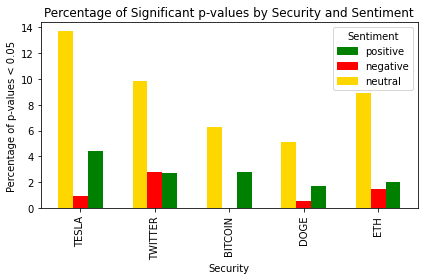

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Define colors for each sentiment
sentiment_colors = {'positive': 'green',
                    'negative': 'red', 'neutral': '#FFD700'}

# Initialize empty lists to store security names, sentiments, and p-value counts
securities = []
sentiments = []
p_value_percentages = []
bar_colors = []

# Iterate over securities and sentiments
for security in tweet_dict_copy.keys():
    sentiment_list = []
    p_value_list = []
    total_tweets = 0
    for sentiment, df in tweet_dict[security].items():
        current_df = tweet_dict_copy[security][sentiment]
        sentiment_list.append(sentiment)
        p_value_count = np.sum(current_df['p_value'] < 0.05)
        p_value_list.append(p_value_count)
        total_tweets += len(current_df)
    securities.append(security)
    sentiments.append(sentiment_list)
    p_value_percentages.append(
        [p_value_count / total_tweets * 100 for p_value_count in p_value_list])
    bar_colors.extend([sentiment_colors[s] for s in sentiment_list])

# Plotting
fig, ax = plt.subplots()
width = 0.2  # Width of each bar
x = np.arange(len(securities))

for i, sentiment_list in enumerate(sentiments):
    x_shift = x[i] - (len(sentiment_list) - 1) * width / 2
    for j, sentiment in enumerate(sentiment_list):
        ax.bar(x_shift + j * width,
               p_value_percentages[i][j], width=width, color=sentiment_colors[sentiment])

ax.set_xticks(x)
ax.set_xticklabels(securities, rotation=90)
ax.set_ylabel("Percentage of p-values < 0.05")
ax.set_xlabel("Security")
ax.set_title("Percentage of Significant p-values by Security and Sentiment")

# Create a legend for sentiments and colors
legend_elements = [plt.Rectangle((0, 0), 1, 1, color=color, label=sentiment)
                   for sentiment, color in sentiment_colors.items()]
ax.legend(handles=legend_elements, title='Sentiment')

plt.tight_layout()
plt.show()
